[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **Components Recognition/Detection in Hospital Rooms**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

This notebook demonstrates an end-to-end pipeline for **detecting and segmenting components in hospital rooms** using a fine-tuned YOLO segmentation model.

### Workflow

| Step | Description |
|------|-------------|
| **1. Install Dependencies** | Set up `ultralytics` and clone annotation utilities |
| **2. Import Annotation Utilities** | Load the manifest-to-YOLO conversion function |
| **3. Convert Annotations** | Extract labeled frames from videos and split into train/val/test sets |
| **4. Check GPU Status** | Verify CUDA memory availability before training |
| **5. Train Model** | Fine-tune YOLOv11m-seg on the hospital room dataset for 100 epochs |
| **6. Load Best Weights** | Load the top-performing checkpoint for inference |
| **7. Image Inference** | Predict and visualize results on a single validation image |
| **8. Video Inference (Sample 1)** | Run detection on the first hospital room video |
| **9. Video Inference (Sample 2)** | Run detection on the second hospital room video |

### Key Details
- **Model:** YOLOv11m-seg (instance segmentation)
- **Task:** Detect hospital room components (beds, monitors, equipment, etc.)
- **Dataset:** Custom-annotated video frames in YOLO segmentation format
- **Output:** Annotated images and videos with bounding boxes and segmentation masks

---
## 1. Install Dependencies

Install the required packages (`ultralytics` for YOLO) and clone the annotation utility repository if not already present.

In [ ]:
# !git clone https://github.com/Labellerr/yolo_finetune_utils.git
# !pip install ultralytics

---
## 2. Import Annotation Utilities

Import the annotation conversion function from the `yolo_finetune_utils` package to transform video annotations into YOLO-compatible format.

In [1]:
from yolo_finetune_utils.video_annotation import convert_from_manifest

---
## 3. Convert Video Annotations to YOLO Format

Parse the annotation manifest and extract labeled frames from the source videos, splitting them into train, validation, and test sets for model training.

In [3]:
ANNOTATION_FILE = "annotations.json"
VIDEOS_DIRECTORY = "video"


convert_from_manifest(
    manifest_path=ANNOTATION_FILE,
    videos_dir=VIDEOS_DIRECTORY,
    task="segmentation",  # or "bbox"
    split_ratio=(0.5, 0.4, 0.1)
)

Loading manifest from: annotations.json
Found 2 file export(s) in manifest.


  ✓ Downloaded annotations for: sample1.mp4


  ✓ Downloaded annotations for: sample2.mp4



Merged 2 annotation(s) into: d:\Professional\Projects\hospital_analysis\merged_annotations.json
Using split ratio: Train=0.5, Val=0.4, Test=0.1
Creating output directory structure in: model_dataset
Loading JSON annotation file...
Found classes: ['IV pole', 'Infusion setup', 'Mattress', 'Sink', 'Soap dispenser', 'bed rails', 'humidifier unit', 'pillow', 'stool', 'vital signs monitor']
Aggregating annotations from JSON...


Processing files in JSON: 100%|██████████| 2/2 [00:00<00:00,  5.66it/s]


...

Processing val set (292 frames)...


Exporting val set: 100%|██████████| 292/292 [00:16<00:00, 18.08it/s]


Processing test set (73 frames)...


Exporting test set: 100%|██████████| 73/73 [00:04<00:00, 15.56it/s]


Creating data.yaml file...

Conversion complete! ✨
Dataset saved to: d:\Professional\Projects\hospital_analysis\model_dataset
YAML file saved to: d:\Professional\Projects\hospital_analysis\model_dataset\data.yaml


---
## 4. Check GPU Memory Status

Verify CUDA availability and inspect GPU memory allocation to ensure sufficient resources before training.

In [1]:
import torch
torch.cuda.empty_cache()

# Check GPU memory status
print(f"Allocated: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB")
print(f"Cached: {torch.cuda.memory_reserved(0)/1024**3:.2f} GB")
print(f"Free: {torch.cuda.mem_get_info(0)[0]/1024**3:.2f} GB")

Allocated: 0.00 GB
Cached: 0.00 GB
Free: 6.88 GB


---
## 5. Train the Segmentation Model

Fine-tune the YOLOv11m-seg model on the prepared hospital room dataset for 100 epochs with instance segmentation enabled.

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo26m-seg.pt")

# Train the model
results = model.train(
    data=r"model_dataset\data.yaml",  # Path to your dataset YAML file
    epochs=100,                         # Number of training epochs
    imgsz=640,                         # Image size
    batch=4,                          # Batch size
    device=0,                          # GPU device (0 for first GPU, 'cpu' for CPU)
    workers=4,                         # Number of dataloader workers
)

---
## 6. Load the Best Trained Model

Load the best-performing model weights saved during training for use in inference.

In [1]:
from ultralytics import YOLO

model = YOLO(r"runs\segment\train\weights\best.pt")

---
## 7. Run Inference on a Single Image

Predict hospital room components on a validation image and display the annotated result with bounding boxes and segmentation masks.


image 1/1 d:\Professional\Projects\hospital_analysis\model_dataset\images\val\sample2_frame_184.jpg: 384x640 7 Infusion setups, 1 Mattress, 1 humidifier unit, 4 vital signs monitors, 118.3ms
Speed: 2.7ms preprocess, 118.3ms inference, 3.4ms postprocess per image at shape (1, 3, 384, 640)


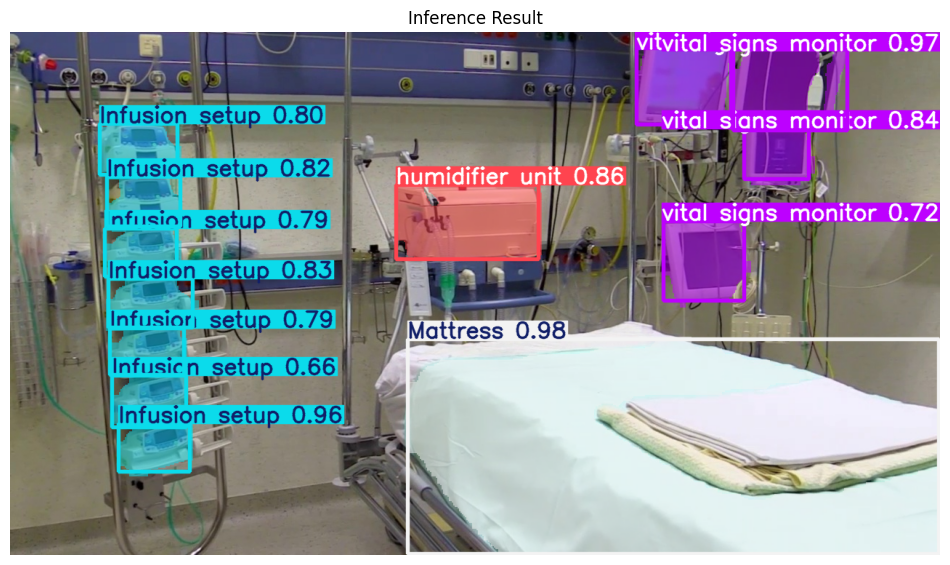

In [6]:
import matplotlib.pyplot as plt
import cv2

# Provide the path to an image you want to test
IMAGE_PATH = r"model_dataset\images\val\sample2_frame_184.jpg" # <--- Change to your image path
# Run prediction
results = model.predict(source=IMAGE_PATH, conf=0.25, save=False)
# Get the first result and generate the annotated image
annotated_img = results[0].plot()
# Convert the image from BGR (OpenCV format) to RGB (Matplotlib format)
annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
# Display the image in the notebook
plt.figure(figsize=(12, 8))
plt.imshow(annotated_img_rgb)
plt.axis("off")
plt.title("Inference Result")
plt.show()

---
## 8. Run Inference on Video (Sample 1)

Apply the trained model to the first sample video, saving the annotated output with detected hospital room components.

In [2]:
VIDEO_PATH = r"video\sample1.mp4"

# Run inference on video
results = model.predict(
    source=VIDEO_PATH,
    save=True,
    conf=0.20,
    iou=0.7,
    show=False,
    show_labels=True,
    stream = True
)

for result in results:
    pass


video 1/1 (frame 1/330) d:\Professional\Projects\hospital_analysis\video\sample1.mp4: 384x640 1 Sink, 1 Soap dispenser, 2 bed railss, 1 stool, 46.6ms
video 1/1 (frame 2/330) d:\Professional\Projects\hospital_analysis\video\sample1.mp4: 384x640 1 Sink, 1 Soap dispenser, 2 bed railss, 1 stool, 16.2ms
video 1/1 (frame 3/330) d:\Professional\Projects\hospital_analysis\video\sample1.mp4: 384x640 1 Sink, 1 Soap dispenser, 2 bed railss, 1 stool, 14.9ms
video 1/1 (frame 4/330) d:\Professional\Projects\hospital_analysis\video\sample1.mp4: 384x640 1 Sink, 1 Soap dispenser, 2 bed railss, 1 stool, 13.4ms
video 1/1 (frame 5/330) d:\Professional\Projects\hospital_analysis\video\sample1.mp4: 384x640 1 Sink, 1 Soap dispenser, 2 bed railss, 1 stool, 13.6ms
video 1/1 (frame 6/330) d:\Professional\Projects\hospital_analysis\video\sample1.mp4: 384x640 1 Sink, 1 Soap dispenser, 2 bed railss, 1 stool, 14.7ms
video 1/1 (frame 7/330) d:\Professional\Projects\hospital_analysis\video\sample1.mp4: 384x640 1 Sin

---
## 9. Run Inference on Video (Sample 2)

Run the same inference pipeline on the second sample video to validate model generalization across different hospital room footage.

In [3]:
VIDEO_PATH = r"video\sample2.mp4"

# Run inference on video
results = model.predict(
    source=VIDEO_PATH,
    save=True,
    conf=0.20,
    iou=0.7,
    show=False,
    show_labels=True,
    stream = True
)

for result in results:
    pass


video 1/1 (frame 1/400) d:\Professional\Projects\hospital_analysis\video\sample2.mp4: 384x640 7 Infusion setups, 1 Mattress, 1 humidifier unit, 1 pillow, 2 vital signs monitors, 85.9ms
video 1/1 (frame 2/400) d:\Professional\Projects\hospital_analysis\video\sample2.mp4: 384x640 7 Infusion setups, 1 Mattress, 1 humidifier unit, 1 pillow, 2 vital signs monitors, 12.8ms
video 1/1 (frame 3/400) d:\Professional\Projects\hospital_analysis\video\sample2.mp4: 384x640 7 Infusion setups, 1 Mattress, 1 humidifier unit, 1 pillow, 2 vital signs monitors, 17.8ms
video 1/1 (frame 4/400) d:\Professional\Projects\hospital_analysis\video\sample2.mp4: 384x640 8 Infusion setups, 1 Mattress, 1 humidifier unit, 1 pillow, 2 vital signs monitors, 16.2ms
video 1/1 (frame 5/400) d:\Professional\Projects\hospital_analysis\video\sample2.mp4: 384x640 8 Infusion setups, 1 Mattress, 1 humidifier unit, 1 pillow, 2 vital signs monitors, 15.7ms
video 1/1 (frame 6/400) d:\Professional\Projects\hospital_analysis\video\s

---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
